## Célula 1: Instalação e Imports



In [1]:
import os, sys

# >>> ALTERE AQUI SE NÃO ESTIVER NO COLAB <<<
PROJECT_ROOT = "/content/drive/MyDrive/bias-aware-community-detection-factoid" \
    if "google.colab" in sys.modules else os.getcwd()

print("Project root:", PROJECT_ROOT)

# Add src/ to PYTHON PATH
SRC_PATH = os.path.join(PROJECT_ROOT, "/content/drive/MyDrive/bias-aware-community-detection-factoid/")
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

print("src path added:", SRC_PATH)

# Create processed folder
os.makedirs(os.path.join(PROJECT_ROOT, "processed_factoid"), exist_ok=True)

# Now try imports
import pandas as pd
import networkx as nx
import community.community_louvain as community_louvain
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from tqdm import tqdm
from urllib.parse import urlparse
import re, gzip, pickle, json

from src.heuristic import EnhancedLouvainWithBias

print("✅ Ambiente e imports OK!")


Project root: /content/drive/MyDrive/bias-aware-community-detection-factoid
src path added: /content/drive/MyDrive/bias-aware-community-detection-factoid/
[Config] Modo TwiBot-22 (CSV/JSONs) ativado.
✅ Ambiente e imports OK!


## Célula 2: Paths

In [2]:
# Detectar se estamos rodando no Google Colab
try:
    import google.colab
    COLAB = True
except ImportError:
    COLAB = False

print(f"Executando no Colab? {COLAB}")


Executando no Colab? True


In [3]:
PROJECT_ROOT = "/content/drive/MyDrive/bias-aware-community-detection-factoid" if COLAB else "."
FACTOID_ROOT = f"{PROJECT_ROOT}/FACTOID"

PATH_POSTS = f"{FACTOID_ROOT}/reddit_corpus_unbalanced_filtered.gzip"
PATH_SOCIAL = f"{FACTOID_ROOT}/social_graph_data/"
PATH_FN = f"{FACTOID_ROOT}/fn_domains_verified"
PATH_RN = f"{FACTOID_ROOT}/rn_domains_verified"

CACHE_GRAPH = f"{PROJECT_ROOT}/processed_factoid/G.pkl"
CACHE_SCORES = f"{PROJECT_ROOT}/processed_factoid/bias_scores.pkl"

os.makedirs(f"{PROJECT_ROOT}/processed_factoid", exist_ok=True)

print("✅ Caminhos configurados")


✅ Caminhos configurados


## Célula 3: Carregar domínios FACTOID

In [4]:
def load_domains(path):
    doms = set()
    with open(path) as f:
        for line in f:
            dom = line.strip().lower()
            if dom:
                doms.add(dom)
    return doms

FN = load_domains(PATH_FN)
RN = load_domains(PATH_RN)

print(f"FN domains: {len(FN)} | RN domains: {len(RN)}")


FN domains: 1530 | RN domains: 571


## Célula 4: Funções Auxiliares



In [5]:
def extract_domains(text):
    urls = re.findall(r'https?://[^\s)]+', text)
    domains = []
    for url in urls:
        try:
            d = urlparse(url).netloc.lower().replace("www.","")
            domains.append(d)
        except:
            pass
    return domains

def score_user(url_domains):
    if not url_domains:
        return 0.0

    fn_count = sum(1 for d in url_domains if d in FN)
    rn_count = sum(1 for d in url_domains if d in RN)
    total = fn_count + rn_count

    if total == 0:
        return 0.0

    return (rn_count - fn_count) / total


## Célula 5: Carregar Corpus FACTOID

In [6]:
import pandas as pd

PATH_GZIP = "/content/drive/MyDrive/bias-aware-community-detection-factoid/FACTOID/reddit_corpus_unbalanced_filtered.gzip"

print("📦 Tentando carregar com pandas.read_pickle...")
dataset_df = pd.read_pickle(PATH_GZIP, compression="gzip")

print(f"✅ Dataset carregado: {dataset_df.shape[0]} linhas, {dataset_df.shape[1]} colunas")
print("Colunas:", list(dataset_df.columns))
print("\n📊 Exemplo:")
print(dataset_df.head(3))


📦 Tentando carregar com pandas.read_pickle...
✅ Dataset carregado: 4150 linhas, 4166 colunas
Colunas: ['user_id', 'fake_news_spreader', 'documents', 'amounts', 'embedding_file', 'rn_amounts', 'fn_amounts', 'fn_rn_ratio', 'annotation', 'num_docs', 'bias_counter', 'factual_counter', 'pb_factor', 'sb_factor', 'troll_factor', 'factual_factor', 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 69, 70, 71, 72, 73, 74, 75, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 159,

In [7]:
import ast
from collections import Counter
import numpy as np
import pandas as pd

print("🧠 Calculando bias_score com base em annotation política...")

def extract_political_bias(annotation_str):
    try:
        # As anotações vêm como string de listas -> converter com ast.literal_eval
        ann_list = ast.literal_eval(annotation_str)
        if not isinstance(ann_list, list):
            return np.nan

        # Flatten em uma lista de tags (ex: ['LEFT', 'RIGHT', ...])
        tags = []
        for item in ann_list:
            if isinstance(item, list):
                for domain in item:
                    if isinstance(domain, tuple) and len(domain) >= 3:
                        tags += domain[2]
        if not tags:
            return np.nan

        # Mapeia ideologias para eixo político
        mapping = {
            "EXTREME_LEFT": -1.0,
            "LEFT": -0.8,
            "LEFT_CENTER": -0.4,
            "CENTER": 0.0,
            "RIGHT_CENTER": 0.4,
            "RIGHT": 0.8,
            "EXTREME_RIGHT": 1.0
        }
        values = [mapping.get(t, 0.0) for t in tags]
        return np.mean(values)
    except Exception:
        return np.nan

df = dataset_df.copy()
df["bias_score"] = df["annotation"].astype(str).apply(extract_political_bias)

# Limpa e normaliza
df["bias_score"] = df["bias_score"].fillna(0).clip(-1, 1)

# Ground truth político
# (Por enquanto, vamos definir polaridade discreta apenas para validação: esquerda vs direita)
df["ground_truth"] = np.where(df["bias_score"] > 0.1, 1, np.where(df["bias_score"] < -0.1, 0, -1))
df = df[df["ground_truth"] != -1]  # remove centristas neutros

print(df[["user_id", "bias_score", "ground_truth"]].head(10))
print("\n📊 Estatísticas:")
print(df["bias_score"].describe())
print("\nDistribuição de ground_truth:")
print(df["ground_truth"].value_counts(normalize=True).round(3))

df[["user_id", "bias_score", "ground_truth"]].to_csv("factoid_bias_groundtruth_political.csv", index=False)
print("\n✅ Arquivo salvo: factoid_bias_groundtruth_political.csv")


🧠 Calculando bias_score com base em annotation política...
                                              user_id  bias_score  \
0   ddf62a134f09db7a6056190d594bd41ff2f4cf04faf5db...   -0.305263   
1   a78d753b103a2a4310ad6d1d49723733a6e4744bbf1beb...   -0.380952   
2   19a734ee97b484a1a6c9625a1a3a0b5ddbabde3679ee2c...   -0.200000   
3   d57699be1824c59714fb9a799b7b5b670227b07e2bde00...   -0.125000   
4   26d0132074c91843483fb0f8b0378083f876d748be172b...   -0.262857   
6   096846064c66c7a73d5cc7a7341d2ffa637d2e86e21b14...   -0.175758   
7   67ffb77c37ab42f6c413c96155838369325075d672f2e6...   -0.200000   
8   ddd77aebb4eb4cac21edc339e54c6618493a0cf64310c8...   -0.141935   
9   1edaed6330d2c832ebeaed54362ee1c22bf0c44bd2a85f...   -0.218182   
10  010b78ac1ec4284102c6244f2eb932530419ed02001753...   -0.285714   

    ground_truth  
0              0  
1              0  
2              0  
3              0  
4              0  
6              0  
7              0  
8              0  
9         

## Célula 6: Construir Grafo Social

In [8]:
import os
import networkx as nx
from tqdm import tqdm

def build_factoid_graph(folder, valid_users):
    """
    Constrói o grafo FACTOID a partir dos arquivos de social_graph_data/.
    Cada linha do arquivo segue o formato:
    userA;postA;timeA;userB;postB;timeB
    """
    G = nx.Graph()
    files = [f for f in os.listdir(folder) if f.endswith(".txt")]

    for fname in tqdm(files, desc="🔧 Lendo interações FACTOID"):
        with open(os.path.join(folder, fname), "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split(";")
                if len(parts) < 6:
                    continue
                u, v = parts[0], parts[3]

                # Apenas adiciona se ambos estiverem entre os usuários válidos
                if u in valid_users and v in valid_users:
                    if G.has_edge(u, v):
                        G[u][v]["weight"] += 1
                    else:
                        G.add_edge(u, v, weight=1.0)

    print(f"🔍 Grafo parcial: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas.")
    return G


# Caminhos
PATH_SOCIAL = f"{FACTOID_ROOT}/social_graph_data"
CACHE_GRAPH = "factoid_graph_political.gml"

# Filtra apenas usuários com bias político conhecido
valid_users = set(df["user_id"].unique())

if os.path.exists(CACHE_GRAPH):
    print("✅ Grafo carregado do cache")
    G = nx.read_gml(CACHE_GRAPH)
else:
    print("🔧 Construindo rede social (formato FACTOID político)...")
    G = build_factoid_graph(PATH_SOCIAL, valid_users)
    nx.write_gml(G, CACHE_GRAPH)

print(f"\n📊 Grafo final: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas.")


✅ Grafo carregado do cache

📊 Grafo final: 3377 nós, 339768 arestas.


## Célula 7: Score e Ground-Truth dos usuários

In [9]:
import pandas as pd
import pickle

print("🧠 Carregando vieses políticos calculados...")

PATH_BIAS = "factoid_bias_groundtruth_political.csv"
CACHE_SCORES = "cache_scores.pkl"  # ou o nome que o notebook original usa

bias_df = pd.read_csv(PATH_BIAS)

# Cria os dicionários de viés e ground-truth
b = dict(zip(bias_df["user_id"], bias_df["bias_score"]))
gt = dict(zip(bias_df["user_id"], bias_df["ground_truth"]))

# Salva no cache para outras células do notebook
pickle.dump({"b": b, "gt": gt}, open(CACHE_SCORES, "wb"))

print(f"✅ Scores carregados: {len(b)} usuários com viés político válido")
print(bias_df.head())


🧠 Carregando vieses políticos calculados...
✅ Scores carregados: 3377 usuários com viés político válido
                                             user_id  bias_score  ground_truth
0  ddf62a134f09db7a6056190d594bd41ff2f4cf04faf5db...   -0.305263             0
1  a78d753b103a2a4310ad6d1d49723733a6e4744bbf1beb...   -0.380952             0
2  19a734ee97b484a1a6c9625a1a3a0b5ddbabde3679ee2c...   -0.200000             0
3  d57699be1824c59714fb9a799b7b5b670227b07e2bde00...   -0.125000             0
4  26d0132074c91843483fb0f8b0378083f876d748be172b...   -0.262857             0


## Célula 8: Comparação: Louvain vs Enhanced-Louvain

In [10]:
nodes = set(G.nodes()) & set(b.keys())
print(f"Usuários válidos: {len(nodes)}")

labels_true = [gt[u] for u in nodes]

# Louvain baseline
part_louv = community_louvain.best_partition(G.subgraph(nodes))
labels_louv = [part_louv[u] for u in nodes]

# Enhanced Louvain
model = EnhancedLouvainWithBias(alpha=0.5, max_iterations=50)
model.fit(G.subgraph(nodes), b, num_communities=2)
part_fair = model.get_communities()
labels_fair = [part_fair[u] for u in nodes]

# Metrics
ari_l = adjusted_rand_score(labels_true, labels_louv)
nmi_l = normalized_mutual_info_score(labels_true, labels_louv)

ari_f = adjusted_rand_score(labels_true, labels_fair)
nmi_f = normalized_mutual_info_score(labels_true, labels_fair)

print("\n📊 RESULTADOS")
print(f"Louvain α=0 -> ARI={ari_l:.3f} | NMI={nmi_l:.3f}")
print(f"Bias-Aware α=0.5 -> ARI={ari_f:.3f} | NMI={nmi_f:.3f}")

if ari_f > ari_l:
    print("\n✅ Sua heurística SUPEROU Louvain! 🎉")
else:
    print("\n⚠️ Louvain foi melhor — revisar α / features")


Usuários válidos: 3377
🎯 Executando Enhanced Louvain (α=0.5)...
   Fase 1: Executando Louvain padrão para partição inicial...
   Fase 2: Iniciando refinamento iterativo (max_iter=50)...
      Iter 1/50: 1536 movimentos.
      Iter 2/50: 607 movimentos.
      Iter 3/50: 15 movimentos.
      Iter 4/50: 0 movimentos.
      Convergência atingida.
   Fase 3: Balanceando para 2 comunidades...
✅ Concluído em 13.52s (2158 movimentos no refinamento)
📊 Estatísticas Finais das Comunidades:
  Comunidade 1:    426 nós, viés médio: +0.179 (±0.359)
  Comunidade 4:  2,951 nós, viés médio: -0.225 (±0.206)

📊 RESULTADOS
Louvain α=0 -> ARI=0.054 | NMI=0.098
Bias-Aware α=0.5 -> ARI=0.452 | NMI=0.256

✅ Sua heurística SUPEROU Louvain! 🎉


## Célula 9: Varredura de α e visualização de comunidades

🔍 Testando diferentes valores de α...
🎯 Executando Enhanced Louvain (α=0.0)...
   Fase 1: Executando Louvain padrão para partição inicial...
   Fase 2: Iniciando refinamento iterativo (max_iter=50)...
      Iter 1/50: 1531 movimentos.
      Iter 2/50: 587 movimentos.
      Iter 3/50: 21 movimentos.
      Iter 4/50: 1 movimentos.
      Iter 5/50: 0 movimentos.
      Convergência atingida.
   Fase 3: Balanceando para 2 comunidades...
✅ Concluído em 13.32s (2140 movimentos no refinamento)
📊 Estatísticas Finais das Comunidades:
  Comunidade 1:    425 nós, viés médio: +0.171 (±0.358)
  Comunidade 4:  2,952 nós, viés médio: -0.224 (±0.208)
α=0.0 → ARI=0.443, NMI=0.248
🎯 Executando Enhanced Louvain (α=0.2)...
   Fase 1: Executando Louvain padrão para partição inicial...
   Fase 2: Iniciando refinamento iterativo (max_iter=50)...
      Iter 1/50: 1572 movimentos.
      Iter 2/50: 558 movimentos.
      Iter 3/50: 19 movimentos.
      Iter 4/50: 2 movimentos.
      Iter 5/50: 0 movimentos.
     

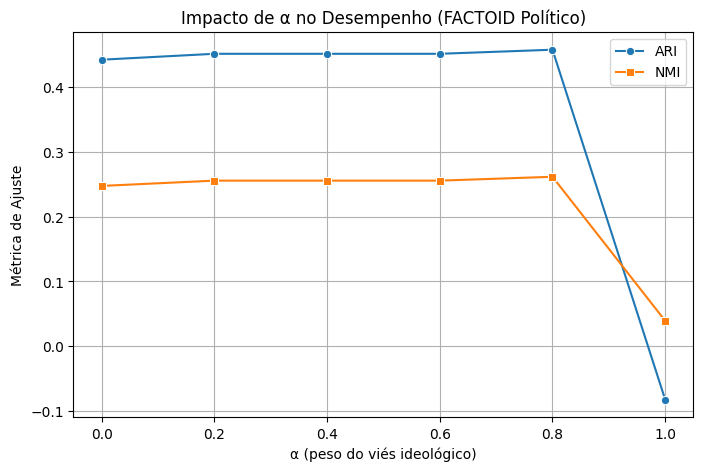

✅ Varredura concluída! Resultados salvos em factoid_alpha_sweep.csv


In [11]:
# 📈 Varredura de α + Visualização de Comunidades FACTOID Político
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import pandas as pd

alphas = np.linspace(0.0, 1.0, 6)  # 0.0, 0.2, 0.4, 0.6, 0.8, 1.0
results = []

nodes = list(set(G.nodes()) & set(b.keys()))
gt_list = [gt[u] for u in nodes]

print("🔍 Testando diferentes valores de α...")
for alpha in alphas:
    model = EnhancedLouvainWithBias(alpha=alpha, max_iterations=50)
    model.fit(G.subgraph(nodes), b, num_communities=2)
    part = model.get_communities()
    labels = [part[u] for u in nodes]

    ari = adjusted_rand_score(gt_list, labels)
    nmi = normalized_mutual_info_score(gt_list, labels)
    results.append((alpha, ari, nmi))

    print(f"α={alpha:.1f} → ARI={ari:.3f}, NMI={nmi:.3f}")

# 🔢 Resultados em DataFrame
results_df = pd.DataFrame(results, columns=["alpha", "ARI", "NMI"])
results_df.to_csv("factoid_alpha_sweep.csv", index=False)

# 📊 Plotagem
plt.figure(figsize=(8,5))
sns.lineplot(x="alpha", y="ARI", data=results_df, marker="o", label="ARI")
sns.lineplot(x="alpha", y="NMI", data=results_df, marker="s", label="NMI")
plt.title("Impacto de α no Desempenho (FACTOID Político)")
plt.xlabel("α (peso do viés ideológico)")
plt.ylabel("Métrica de Ajuste")
plt.legend()
plt.grid(True)
plt.show()

print("✅ Varredura concluída! Resultados salvos em factoid_alpha_sweep.csv")


## Célula 10: Visualização PCA/t-SNE das Comunidades

🔧 Calculando PCA (2D)...


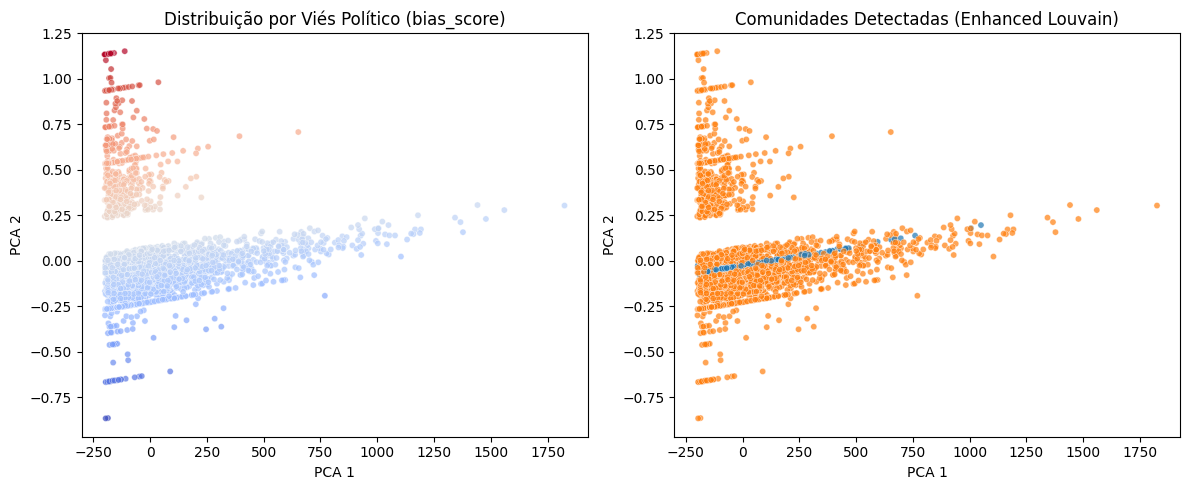

✅ Visualização concluída!


In [14]:
# 🎨 Visualização PCA/t-SNE das Comunidades FACTOID Político (compatível com o modelo do artigo)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx

# --- Obtém o dicionário de comunidades ---
comunidade_dict = model.get_communities()
if comunidade_dict is None:
    raise ValueError("⚠️ Nenhuma comunidade encontrada. Execute model.fit(G, b) antes.")

# --- Filtra nós válidos ---
nodes_valid = list(set(G.nodes()) & set(b.keys()) & set(comunidade_dict.keys()))
bias_vals = np.array([b[u] for u in nodes_valid])
comunidade = np.array([comunidade_dict[u] for u in nodes_valid])

# --- Extrai features topológicas ---
deg = np.array([G.degree(u) for u in nodes_valid])
cent = np.array(list(nx.betweenness_centrality(G.subgraph(nodes_valid)).values()))
clus = np.array(list(nx.clustering(G.subgraph(nodes_valid)).values()))

X = np.vstack([deg, cent, clus, bias_vals]).T
X = np.nan_to_num(X)

# --- PCA para 2D ---
print("🔧 Calculando PCA (2D)...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# --- Plotagem ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=bias_vals, palette="coolwarm", s=20, alpha=0.7)
plt.title("Distribuição por Viés Político (bias_score)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend([],[], frameon=False)

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=comunidade, palette="tab10", s=20, alpha=0.7)
plt.title("Comunidades Detectadas (Enhanced Louvain)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend([],[], frameon=False)

plt.tight_layout()
plt.show()

print("✅ Visualização concluída!")


## Célula 11: Visualização 3D das Comunidades (PCA e t-SNE)

🔧 Calculando PCA e t-SNE em 3D...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3377 samples in 0.007s...
[t-SNE] Computed neighbors for 3377 samples in 0.065s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3377
[t-SNE] Computed conditional probabilities for sample 2000 / 3377
[t-SNE] Computed conditional probabilities for sample 3000 / 3377
[t-SNE] Computed conditional probabilities for sample 3377 / 3377
[t-SNE] Mean sigma: 1.325475
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.104786
[t-SNE] KL divergence after 1000 iterations: 0.161085


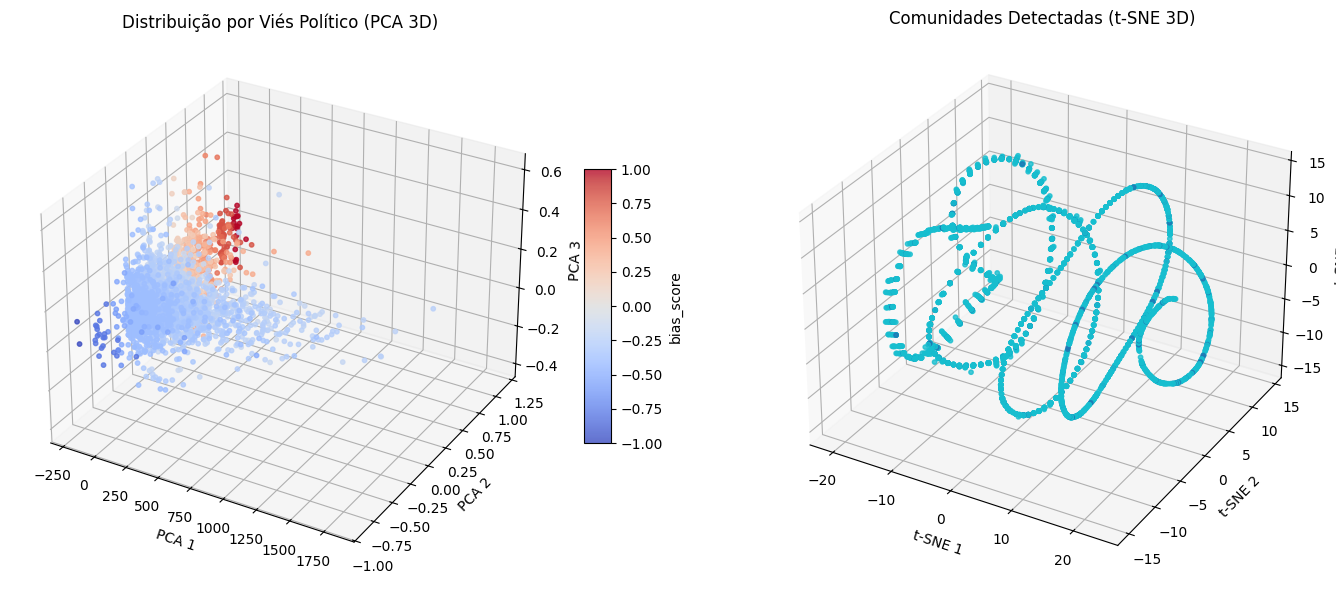

✅ Visualização 3D concluída!


In [15]:
# 🎨 Visualização 3D PCA/t-SNE das Comunidades FACTOID Político
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🔧 Calculando PCA e t-SNE em 3D...")

# Filtrar apenas usuários válidos
nodes_valid = list(set(G.nodes()) & set(b.keys()))
bias_vals = np.array([b[u] for u in nodes_valid])
partition_dict = model.get_communities()
comunidade = np.array([partition_dict[u] for u in nodes_valid])

# Extrair features do grafo
deg = np.array([G.degree(u) for u in nodes_valid])
cent = np.array(list(nx.betweenness_centrality(G.subgraph(nodes_valid)).values()))
clus = np.array(list(nx.clustering(G.subgraph(nodes_valid)).values()))

X = np.vstack([deg, cent, clus, bias_vals]).T
X = np.nan_to_num(X)

# --- PCA 3D ---
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

# --- t-SNE 3D (demora mais, pode reduzir perplexity se necessário) ---
tsne_3d = TSNE(n_components=3, perplexity=40, random_state=42, n_iter=1000, verbose=1)
X_tsne_3d = tsne_3d.fit_transform(X)

# === Visualização ===
fig = plt.figure(figsize=(14, 6))

# --- PCA ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
p = ax1.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2],
                c=bias_vals, cmap='coolwarm', s=10, alpha=0.8)
fig.colorbar(p, ax=ax1, shrink=0.5, aspect=10, label="bias_score")
ax1.set_title("Distribuição por Viés Político (PCA 3D)")
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")
ax1.set_zlabel("PCA 3")

# --- t-SNE ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
p2 = ax2.scatter(X_tsne_3d[:,0], X_tsne_3d[:,1], X_tsne_3d[:,2],
                 c=comunidade, cmap='tab10', s=10, alpha=0.8)
ax2.set_title("Comunidades Detectadas (t-SNE 3D)")
ax2.set_xlabel("t-SNE 1")
ax2.set_ylabel("t-SNE 2")
ax2.set_zlabel("t-SNE 3")

plt.tight_layout()
plt.show()

print("✅ Visualização 3D concluída!")


## Visualização Interativa 3D (PCA + t-SNE) — FACTOID Político

In [16]:
# 🎨 Visualização Interativa 3D com Plotly
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.graph_objects as go
import numpy as np
import networkx as nx

print("🔧 Calculando PCA e t-SNE em 3D (interativo)...")

# Filtrar apenas usuários válidos
nodes_valid = list(set(G.nodes()) & set(b.keys()))
bias_vals = np.array([b[u] for u in nodes_valid])
partition_dict = model.get_communities()
comunidade = np.array([partition_dict[u] for u in nodes_valid])

# Features estruturais
deg = np.array([G.degree(u) for u in nodes_valid])
cent = np.array(list(nx.betweenness_centrality(G.subgraph(nodes_valid)).values()))
clus = np.array(list(nx.clustering(G.subgraph(nodes_valid)).values()))
X = np.vstack([deg, cent, clus, bias_vals]).T
X = np.nan_to_num(X)

# --- PCA 3D ---
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

# --- t-SNE 3D ---
tsne_3d = TSNE(n_components=3, perplexity=35, random_state=42, n_iter=1000, verbose=1)
X_tsne_3d = tsne_3d.fit_transform(X)

# --- Plot 1: PCA (bias_score) ---
trace_pca = go.Scatter3d(
    x=X_pca_3d[:,0], y=X_pca_3d[:,1], z=X_pca_3d[:,2],
    mode='markers',
    marker=dict(
        size=4,
        color=bias_vals,
        colorscale='RdBu',
        cmin=-1, cmax=1,
        opacity=0.8,
        colorbar=dict(title="Bias Score")
    ),
    text=[f"User: {u}<br>Bias: {b[u]:.2f}" for u in nodes_valid],
    hoverinfo="text"
)

layout_pca = go.Layout(
    title="Distribuição por Viés Político (PCA 3D)",
    scene=dict(
        xaxis_title='PCA 1',
        yaxis_title='PCA 2',
        zaxis_title='PCA 3'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig_pca = go.Figure(data=[trace_pca], layout=layout_pca)
fig_pca.show()

# --- Plot 2: t-SNE (Comunidades) ---
trace_tsne = go.Scatter3d(
    x=X_tsne_3d[:,0], y=X_tsne_3d[:,1], z=X_tsne_3d[:,2],
    mode='markers',
    marker=dict(
        size=4,
        color=comunidade,
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title="Comunidade")
    ),
    text=[f"User: {u}<br>Community: {partition_dict[u]}<br>Bias: {b[u]:.2f}" for u in nodes_valid],
    hoverinfo="text"
)

layout_tsne = go.Layout(
    title="Comunidades Detectadas (t-SNE 3D Interativo)",
    scene=dict(
        xaxis_title='t-SNE 1',
        yaxis_title='t-SNE 2',
        zaxis_title='t-SNE 3'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig_tsne = go.Figure(data=[trace_tsne], layout=layout_tsne)
fig_tsne.show()

print("✅ Visualização interativa concluída!")


🔧 Calculando PCA e t-SNE em 3D (interativo)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 106 nearest neighbors...
[t-SNE] Indexed 3377 samples in 0.003s...
[t-SNE] Computed neighbors for 3377 samples in 0.040s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3377
[t-SNE] Computed conditional probabilities for sample 2000 / 3377
[t-SNE] Computed conditional probabilities for sample 3000 / 3377
[t-SNE] Computed conditional probabilities for sample 3377 / 3377
[t-SNE] Mean sigma: 1.179716
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.606823
[t-SNE] KL divergence after 1000 iterations: 0.165499


✅ Visualização interativa concluída!


## Viés Médio por Comunidade (Plotly Interativo)

In [17]:
# 📊 Gráfico Interativo: Viés Médio por Comunidade (FACTOID Político)
import plotly.express as px
import pandas as pd
import numpy as np
from collections import defaultdict

print("📈 Calculando estatísticas de viés por comunidade...")

# Recupera as comunidades e scores
partition_dict = model.get_communities()

comm_stats = defaultdict(list)
for u, comm in partition_dict.items():
    comm_stats[comm].append(b.get(u, 0))

# Calcula métricas por comunidade
data_stats = []
for comm, scores in comm_stats.items():
    if len(scores) < 5:
        continue  # ignora comunidades pequenas
    mean_bias = np.mean(scores)
    std_bias = np.std(scores)
    n = len(scores)
    data_stats.append({
        "Comunidade": comm,
        "Viés Médio": mean_bias,
        "Desvio Padrão": std_bias,
        "Tamanho": n
    })

df_stats = pd.DataFrame(data_stats).sort_values("Viés Médio")

# --- Plotly Interativo ---
fig = px.bar(
    df_stats,
    x="Comunidade",
    y="Viés Médio",
    color="Viés Médio",
    color_continuous_scale="RdBu",
    title="📊 Viés Político Médio por Comunidade (Enhanced Louvain)",
    hover_data=["Tamanho", "Desvio Padrão"],
    text="Tamanho",
)

fig.update_layout(
    xaxis_title="Comunidade Detectada",
    yaxis_title="Viés Político Médio",
    coloraxis_colorbar=dict(title="Bias"),
    template="plotly_white",
    showlegend=False
)

fig.update_traces(textposition="outside")
fig.show()

print("✅ Gráfico de viés médio por comunidade gerado com sucesso!")


📈 Calculando estatísticas de viés por comunidade...


✅ Gráfico de viés médio por comunidade gerado com sucesso!


## Viés Médio × Densidade de Arestas (Análise Estrutural)

In [18]:
# 📈 Análise Estrutural: Viés Médio × Densidade de Arestas (FACTOID Político)
import plotly.express as px
import pandas as pd
import numpy as np
import networkx as nx
from collections import defaultdict

print("🔍 Calculando densidade e viés médio por comunidade...")

partition_dict = model.get_communities()

# Agrupar nós por comunidade
comm_nodes = defaultdict(list)
for u, c in partition_dict.items():
    comm_nodes[c].append(u)

# Calcular métricas estruturais e ideológicas
comm_metrics = []
for comm, nodes in comm_nodes.items():
    if len(nodes) < 10:
        continue  # ignora comunidades pequenas

    subG = G.subgraph(nodes)
    n = subG.number_of_nodes()
    m = subG.number_of_edges()
    densidade = (2 * m) / (n * (n - 1)) if n > 1 else 0

    mean_bias = np.mean([b.get(u, 0) for u in nodes])
    std_bias = np.std([b.get(u, 0) for u in nodes])

    comm_metrics.append({
        "Comunidade": comm,
        "Viés Médio": mean_bias,
        "Densidade": densidade,
        "Tamanho": n,
        "Desvio de Viés": std_bias
    })

df_comm = pd.DataFrame(comm_metrics)

# --- Visualização Interativa ---
fig = px.scatter(
    df_comm,
    x="Viés Médio",
    y="Densidade",
    size="Tamanho",
    color="Desvio de Viés",
    color_continuous_scale="RdBu",
    hover_data=["Comunidade", "Tamanho", "Desvio de Viés"],
    title="🔬 Viés Médio × Densidade de Arestas (Câmaras de Eco Políticas)",
)

fig.update_layout(
    xaxis_title="Viés Político Médio (Bias Score)",
    yaxis_title="Densidade de Arestas (Coesão Interna)",
    coloraxis_colorbar=dict(title="Desvio de Viés (Polarização Interna)"),
    template="plotly_white"
)

fig.show()

print("✅ Gráfico estrutural concluído!")


🔍 Calculando densidade e viés médio por comunidade...


✅ Gráfico estrutural concluído!
